# 0x19 Diffusion Models

> ✨ **This notebook is co-authored with OpenAI Codex**

Today we will explore diffusion models, a class of generative models that is based on a process of gradually adding noise to data and then learning to reverse this process to generate new samples. 

Diffusion models have shown impressive results in generating high-quality images, audio, and even text.

In [1]:
# Setting up environment

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from diffusers import DDPMPipeline, DDPMScheduler
from IPython.display import display

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Forward Diffusion on a Tiny Image

Diffusion begins with a clean sample $x_0$ and gradually corrupts it into noise. We will use a tiny image so every step is easy to inspect.

For a timestep $t$, the scheduler uses a closed-form noising equation:

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

The value $\bar{\alpha}_t$ shrinks as $t$ increases, so the signal fades and the noise dominates. When you look at the plots, focus on this simple shift from image-like to noise-like.

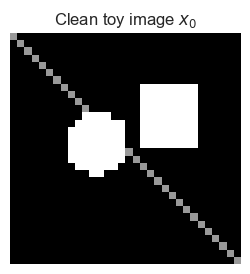

In [2]:
def make_toy_image(size=32):
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, size),
        torch.linspace(-1, 1, size),
        indexing="ij",
    )
    circle = ((xx + 0.25) ** 2 + (yy + 0.05) ** 2 < 0.28**2).float()
    square = ((xx > 0.1) & (xx < 0.65) & (yy > -0.55) & (yy < 0.0)).float()
    diagonal = (torch.abs(yy - xx) < 0.05).float() * 0.6
    image = torch.maximum(torch.maximum(circle, square), diagonal)
    return image * 2 - 1


clean_image = make_toy_image()
clean_batch = clean_image[None, None].to(device)

plt.figure(figsize=(3, 3))
plt.imshow(clean_image, cmap="gray", vmin=-1, vmax=1)
plt.title("Clean toy image $x_0$")
plt.axis("off")
plt.show()
assert clean_batch.shape == (1, 1, 32, 32)

We will use Hugging Face `diffusers` for the diffusion schedule. Think of the scheduler as the notebook's small helper: it stores the noise levels and gives us utilities for adding noise and stepping backward.

,timestep,beta_t,alpha_bar_t
0,0,0.0001,0.9999
10,10,0.0021,0.9879
25,25,0.0051,0.9342
50,50,0.0102,0.7693
75,75,0.0152,0.5580
99,99,0.0200,0.3636


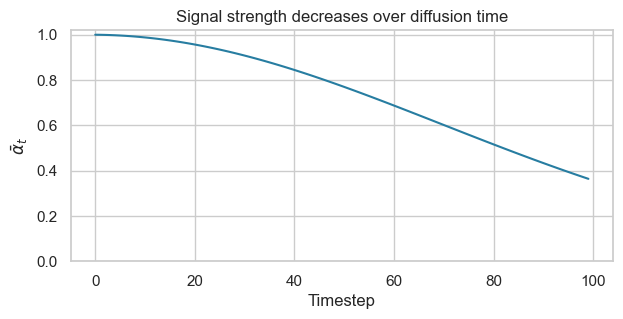

In [3]:
scheduler = DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
)

schedule_df = pd.DataFrame(
    {
        "timestep": np.arange(scheduler.config.num_train_timesteps),  # type: ignore[attr-defined]
        "beta_t": scheduler.betas.cpu().numpy(),  # type: ignore[attr-defined]
        "alpha_bar_t": scheduler.alphas_cumprod.cpu().numpy(),  # type: ignore[attr-defined]
    }
)
display(schedule_df.iloc[[0, 10, 25, 50, 75, 99]].round(4))

plt.figure(figsize=(7, 3))
plt.plot(schedule_df["timestep"], schedule_df["alpha_bar_t"], color="#277da1")
plt.title("Signal strength decreases over diffusion time")
plt.xlabel("Timestep")
plt.ylabel(r"$\bar{\alpha}_t$")
plt.ylim(0, 1.02)
plt.show()
assert np.all(np.diff(schedule_df["alpha_bar_t"]) <= 0)

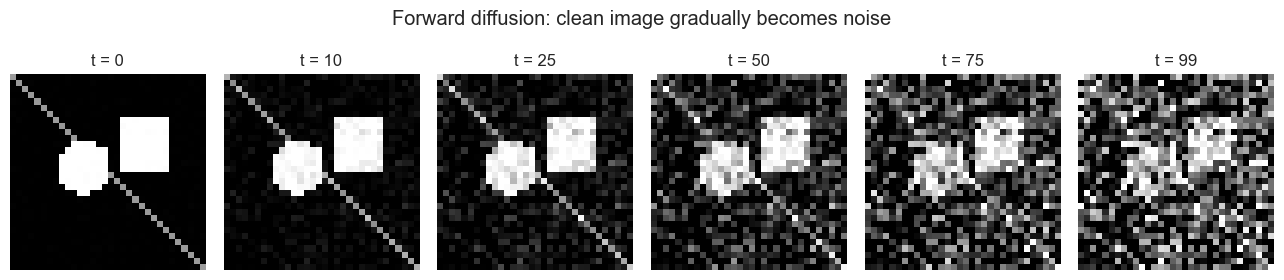

In [4]:
noise = torch.randn_like(clean_batch)
timesteps_to_show = [0, 10, 25, 50, 75, 99]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(13, 3))
for ax, timestep in zip(axes, timesteps_to_show, strict=False):
    t = torch.tensor([timestep], device=device)
    noisy_image = scheduler.add_noise(clean_batch, noise, t)  # type: ignore[attr-defined]
    ax.imshow(noisy_image[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"t = {timestep}")
    ax.axis("off")

fig.suptitle("Forward diffusion: clean image gradually becomes noise")
plt.tight_layout()
plt.show()

> **🤔 THINKING**
>
> - What does the model need to learn if it wants to reverse this process?
> - How does the scheduling of noise levels affect the learning process?

## 2. Training and Reverse Denoising
 
 The forward process is known exactly, and a diffusion model has to learn the reverse process.
 
 Forward noising:
 
 $$
 x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
 $$

 where $\epsilon$ is the noise added at timestep $t$.
 
 Noise-prediction training target is given by
 
 $$
 \mathcal{L} = \lVert\epsilon - \epsilon_\theta(x_t, t)\rVert^2
 $$
 
 where $\epsilon_\theta$ is the model's prediction of the noise given the noised image $x_t$ and the timestep $t$.
 
 At generation time, the model starts from random noise and repeatedly predicts what noise should be removed. The pretrained model below performs that denoising with learned weights, so we can watch the same idea work on real images.


## 3. A Real Pretrained DDPM
 
We swap in a real pretrained denoising model.

[`google/ddpm-cifar10-32`](https://huggingface.co/google/ddpm-cifar10-32) is a small DDPM trained on [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html). To see the kind of original training images it learned from, open the [CIFAR-10 dataset viewer on Hugging Face](https://huggingface.co/datasets/uoft-cs/cifar10).

The model is unconditional, so we cannot ask it for a specific class or text prompt like the generative models you are used to.
It simply starts from random noise and repeatedly applies a learned UNet denoiser.


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

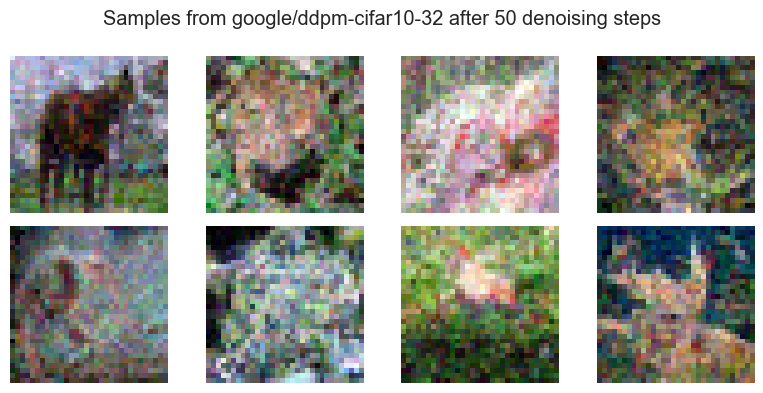

In [5]:
model_id = "google/ddpm-cifar10-32"
num_images = 8
num_inference_steps = 50

try:
    real_pipe = DDPMPipeline.from_pretrained(
        model_id,
        use_safetensors=False,
    ).to(device)
    real_pipe.set_progress_bar_config(disable=False)

    generator_device = device if device.type == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(7)

    real_samples = real_pipe(
        batch_size=num_images,
        num_inference_steps=num_inference_steps,
        generator=generator,
    ).images

    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    for ax, image in zip(axes.ravel(), real_samples, strict=False):
        ax.imshow(image)
        ax.axis("off")

    fig.suptitle(f"Samples from {model_id} after {num_inference_steps} denoising steps")
    plt.tight_layout()
    plt.show()
except OSError:
    print("Could not load the pretrained DDPM weights.")
    print("Refresh the Hugging Face cache, or run this cell once with internet access.")

> **📚 EXERCISE**
 >
 > Try one change at a time, then rerun the nearby cells.
 >
 > - Increase `num_train_timesteps` in the scheduler. How does the forward process change?
 > - Change the synthetic image in `make_toy_image`. Does the noising process care about the image semantics?
 > - Try a smaller or larger `num_inference_steps` for the pretrained DDPM. How do the samples change?
